# **Importación de datos**



In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



##**Análisis de facturación: Ingreso total por cada tienda**

In [2]:
# Verificamos los nombres de las columnas para asegurarnos de que la columna de precios se llama 'Precio'
print(tienda.columns)

Index(['Producto', 'Categoría del Producto', 'Precio', 'Costo de envío',
       'Fecha de Compra', 'Vendedor', 'Lugar de Compra', 'Calificación',
       'Método de pago', 'Cantidad de cuotas', 'lat', 'lon'],
      dtype='object')


In [3]:
# Calculamos el ingreso total de cada tienda (ajusta el nombre de la columna si es distinto)
ingreso_tienda1 = tienda["Precio"].sum()
ingreso_tienda2 = tienda2["Precio"].sum()
ingreso_tienda3 = tienda3["Precio"].sum()
ingreso_tienda4 = tienda4["Precio"].sum()

In [4]:
# Mostramos los resultados
print("Ingreso total por tienda:")
print(f"Tienda 1: ${ingreso_tienda1:,.2f}")
print(f"Tienda 2: ${ingreso_tienda2:,.2f}")
print(f"Tienda 3: ${ingreso_tienda3:,.2f}")
print(f"Tienda 4: ${ingreso_tienda4:,.2f}")

Ingreso total por tienda:
Tienda 1: $1,150,880,400.00
Tienda 2: $1,116,343,500.00
Tienda 3: $1,098,019,600.00
Tienda 4: $1,038,375,700.00


In [5]:
#  Crear un resumen visual
ingresos = pd.DataFrame({
    "Tienda": ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"],
    "Ingreso Total": [ingreso_tienda1, ingreso_tienda2, ingreso_tienda3, ingreso_tienda4]
})

ingresos

,Tienda,Ingreso Total
0,Tienda 1,1.150880e+09
1,Tienda 2,1.116344e+09
2,Tienda 3,1.098020e+09
3,Tienda 4,1.038376e+09


###**Este gráfico muestra claramente cuál tienda genera más o menos ingresos.**

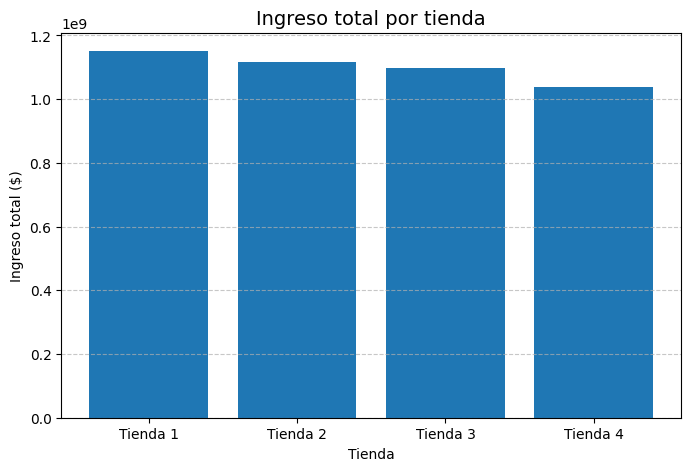

In [6]:
plt.figure(figsize=(8,5))
plt.bar(ingresos["Tienda"], ingresos["Ingreso Total"])
plt.title("Ingreso total por tienda", fontsize=14)
plt.xlabel("Tienda")
plt.ylabel("Ingreso total ($)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

######**La Tienda 1 presenta mayor ingreso total, mientras que la Tienda 4 muestra un rendimiento más bajo.**



---



# 2. Ventas por categoría

##**TIENDA 1**

In [7]:
# --- Ventas por categoría (Tienda 1) ---
ventas_categoria_t1 = tienda["Categoría del Producto"].value_counts()

print("Ventas por categoría - Tienda 1:")
print(ventas_categoria_t1)

Ventas por categoría - Tienda 1:
Categoría del Producto
Muebles                    465
Electrónicos               448
Juguetes                   324
Electrodomésticos          312
Deportes y diversión       284
Instrumentos musicales     182
Libros                     173
Artículos para el hogar    171
Name: count, dtype: int64


##**TIENDA 2**

In [8]:
# Vista previa de los datos de la Tienda 2
tienda2.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Silla de oficina,Muebles,283600.0,15300.0,04/08/2021,Izabela de León,Medellín,1,Nequi,1,6.25184,-75.56359
1,Pandereta,Instrumentos musicales,76800.0,2300.0,26/11/2020,Blanca Ramirez,Medellín,3,Tarjeta de crédito,4,6.25184,-75.56359
2,Cama king,Muebles,443300.0,23800.0,22/10/2021,Izabela de León,Pereira,5,Tarjeta de crédito,10,4.81333,-75.69611
3,Cama king,Muebles,906200.0,46400.0,04/05/2022,Maria Alfonso,Cali,5,Tarjeta de crédito,10,3.43722,-76.52250
4,Silla de oficina,Muebles,397800.0,19400.0,26/02/2022,Lucas Olivera,Bogotá,4,Tarjeta de crédito,3,4.60971,-74.08175


In [9]:
# --- Ventas por categoría (Tienda 2) ---
ventas_categoria_t2 = tienda2["Categoría del Producto"].value_counts()

print("Ventas por categoría - Tienda 2:")
print(ventas_categoria_t2)

Ventas por categoría - Tienda 2:
Categoría del Producto
Muebles                    442
Electrónicos               422
Juguetes                   313
Electrodomésticos          305
Deportes y diversión       275
Instrumentos musicales     224
Libros                     197
Artículos para el hogar    181
Name: count, dtype: int64


##**TIENDA 3**

In [10]:
# Vista previa de los datos de la Tienda 3
tienda3.head()


,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Secadora de ropa,Electrodomésticos,1285100.0,66600.0,17/12/2021,Camila Rivera,Santa Marta,4,Tarjeta de crédito,4,11.24079,-74.19904
1,Mesa de noche,Muebles,290100.0,13600.0,10/02/2021,Maria Alfonso,Cali,3,Tarjeta de crédito,1,3.43722,-76.52250
2,Guitarra acústica,Instrumentos musicales,303500.0,17400.0,22/01/2023,Lucas Olivera,Bogotá,5,Tarjeta de crédito,3,4.60971,-74.08175
3,Balón de voleibol,Deportes y diversión,58800.0,3300.0,22/03/2022,Pedro Gomez,Barranquilla,4,Tarjeta de crédito,6,10.96854,-74.78132
4,Armario,Muebles,521100.0,25900.0,12/01/2022,Blanca Ramirez,Bogotá,1,Tarjeta de crédito,1,4.60971,-74.08175


In [11]:
# --- Ventas por categoría (Tienda 3) ---
ventas_categoria_t3 = tienda3["Categoría del Producto"].value_counts()

print("Ventas por categoría - Tienda 3:")
print(ventas_categoria_t3)

Ventas por categoría - Tienda 3:
Categoría del Producto
Muebles                    499
Electrónicos               451
Juguetes                   315
Electrodomésticos          278
Deportes y diversión       277
Libros                     185
Instrumentos musicales     177
Artículos para el hogar    177
Name: count, dtype: int64


##**TIENDA 4**


In [12]:
# Vista previa de los datos de la Tienda 4
tienda4.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Lavavajillas,Electrodomésticos,1084800.0,56000.0,11/11/2022,Rafael Acosta,Bogotá,4,Tarjeta de crédito,3,4.60971,-74.08175
1,Cama box,Muebles,473800.0,25400.0,03/01/2020,Izabela de León,Cúcuta,5,Tarjeta de crédito,2,7.89391,-72.50782
2,Balón de baloncesto,Deportes y diversión,23700.0,0.0,25/12/2022,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359
3,Modelado predictivo,Libros,57700.0,1300.0,23/11/2021,Lucas Olivera,Medellín,3,Nequi,1,6.25184,-75.56359
4,Auriculares,Electrónicos,138900.0,5600.0,25/04/2022,Blanca Ramirez,Bogotá,4,Tarjeta de crédito,7,4.60971,-74.08175


In [13]:
# --- Ventas por categoría (Tienda 4) ---
ventas_categoria_t4 = tienda4["Categoría del Producto"].value_counts()

print("Ventas por categoría - Tienda 4:")
print(ventas_categoria_t4)

Ventas por categoría - Tienda 4:
Categoría del Producto
Muebles                    480
Electrónicos               451
Juguetes                   338
Deportes y diversión       277
Electrodomésticos          254
Artículos para el hogar    201
Libros                     187
Instrumentos musicales     170
Name: count, dtype: int64




---



####**Cantidad de ventas por categoría de producto - Tiendas**

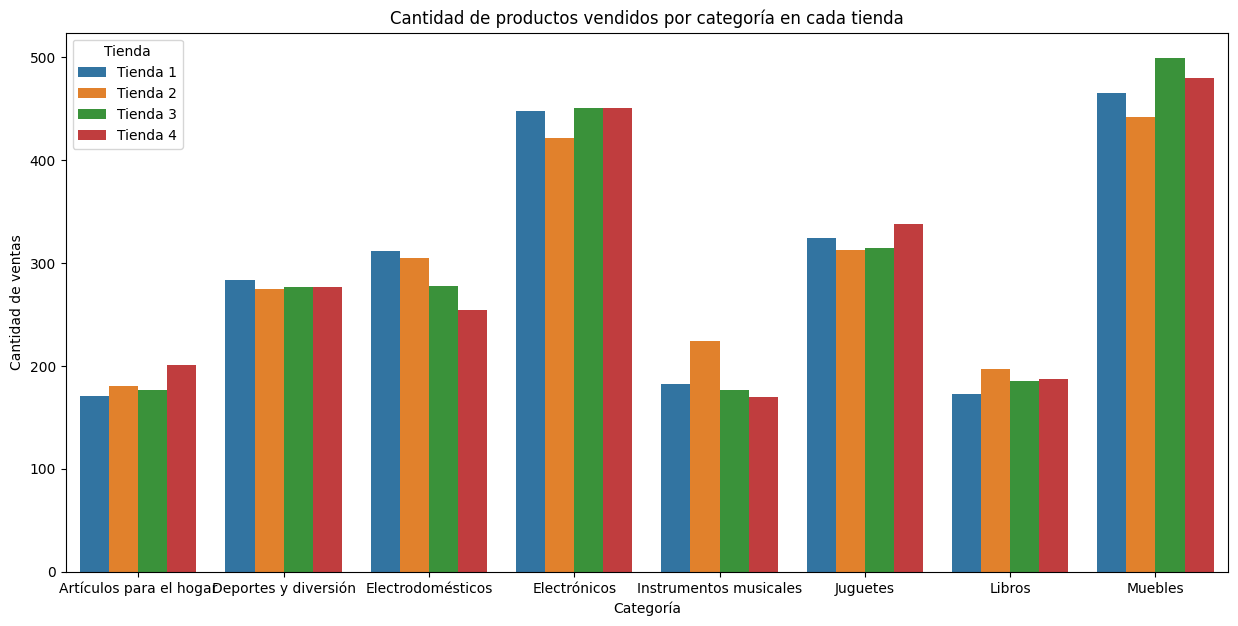

In [14]:


# Concatenar los Dataframes
df = pd.concat([tienda.assign(Tienda='Tienda 1'),
                tienda2.assign(Tienda='Tienda 2'),
                tienda3.assign(Tienda='Tienda 3'),
                tienda4.assign(Tienda='Tienda 4')])

# Agrupar por tienda y categoría, y contar las ventas
df_categoria = df.groupby(["Tienda", "Categoría del Producto"]).size().reset_index(name='Cantidad Vendida')

plt.figure(figsize=(15,7))
sns.barplot(data=df_categoria, x="Categoría del Producto", y="Cantidad Vendida", hue="Tienda")
plt.title("Cantidad de productos vendidos por categoría en cada tienda")
plt.xlabel("Categoría")
plt.ylabel("Cantidad de ventas")
plt.xticks(rotation=0, ha='center')
plt.show()

# 3. Calificación promedio de la tienda


In [15]:
# Calcular el promedio de calificación para cada tienda
valoracion_tienda1 = tienda['Calificación'].mean()
valoracion_tienda2 = tienda2['Calificación'].mean()
valoracion_tienda3 = tienda3['Calificación'].mean()
valoracion_tienda4 = tienda4['Calificación'].mean()

In [16]:
# Crear un DataFrame con los resultados
valoraciones = pd.DataFrame({
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Valoración Media': [valoracion_tienda1, valoracion_tienda2, valoracion_tienda3, valoracion_tienda4]
})

valoraciones

,Tienda,Valoración Media
0,Tienda 1,3.976685
1,Tienda 2,4.037304
2,Tienda 3,4.048326
3,Tienda 4,3.995759


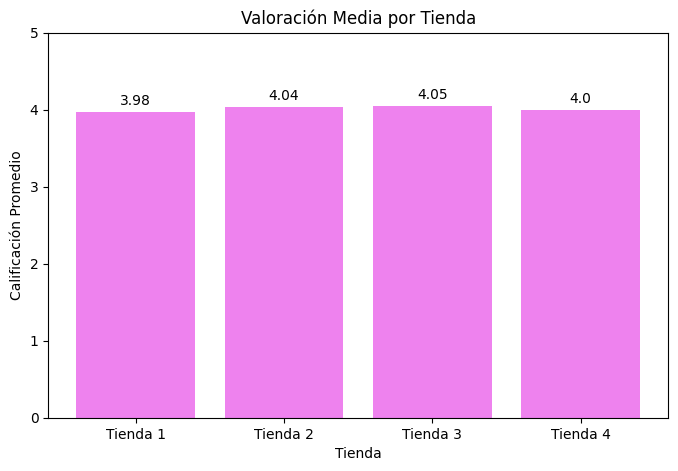

In [17]:
#Gráfico de barras para visualizar cuál tienda tiene mejor calificación promedio:

plt.figure(figsize=(8,5))
plt.bar(valoraciones['Tienda'], valoraciones['Valoración Media'], color='violet')
plt.title('Valoración Media por Tienda')
plt.xlabel('Tienda')
plt.ylabel('Calificación Promedio')
plt.ylim(0,5)

# Mostrar el valor numérico arriba de cada barra (Etiqueta de Datos)
for i, valor in enumerate(valoraciones['Valoración Media']):
    plt.text(i, valor + 0.05, round(valor, 2), ha='center', va='bottom', fontsize=10)

plt.show()

##**Conclusión de la calificación (promedio)**                               

###**Análisis**: Al calcular el promedio de las calificaciones de clientes, se observa que la Tienda 3 presenta la valoración más alta entre todas las tiendas.

### **Conclusión**: Esto indica un mayor nivel de satisfacción general de los clientes con los productos o servicios de la Tienda 3, en comparación con las demás.



---



# 4. Productos más y menos vendidos

##**Comparación general de productos más vendidos entre tiendas**

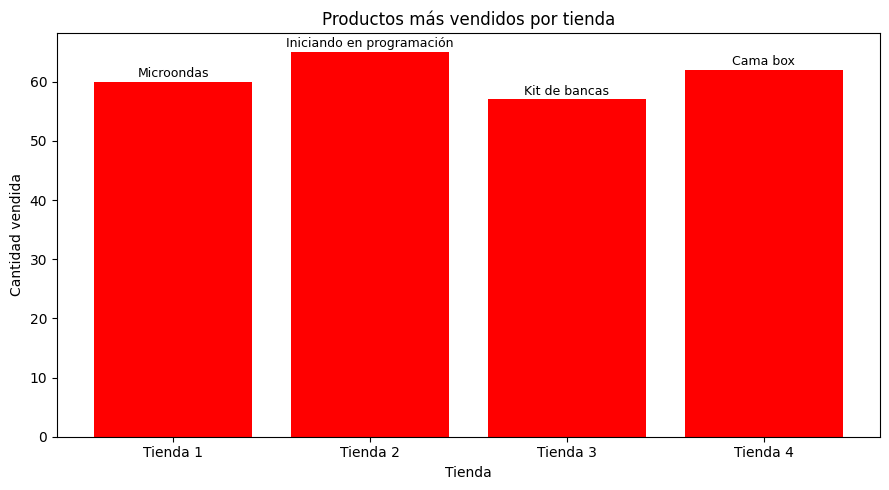

In [18]:
# --- TOP 1 producto más vendido de cada tienda ---

top_productos = {
    "Tienda 1": tienda['Producto'].value_counts().idxmax(),
    "Tienda 2": tienda2['Producto'].value_counts().idxmax(),
    "Tienda 3": tienda3['Producto'].value_counts().idxmax(),
    "Tienda 4": tienda4['Producto'].value_counts().idxmax(),
}

ventas_top = {
    "Tienda 1": tienda['Producto'].value_counts().max(),
    "Tienda 2": tienda2['Producto'].value_counts().max(),
    "Tienda 3": tienda3['Producto'].value_counts().max(),
    "Tienda 4": tienda4['Producto'].value_counts().max(),
}

# Crear DataFrame para graficar
df_top = pd.DataFrame({
    "Tienda": list(top_productos.keys()),
    "Producto más vendido": list(top_productos.values()),
    "Cantidad vendida": list(ventas_top.values())
})

# Mostrar el DataFrame
df_top

# --- Gráfico ---
plt.figure(figsize=(9,5))
plt.bar(df_top["Tienda"], df_top["Cantidad vendida"], color='red')
plt.title("Productos más vendidos por tienda")
plt.xlabel("Tienda")
plt.ylabel("Cantidad vendida")

# Mostrar etiquetas con el nombre del producto centrado y bien visible
for i, valor in enumerate(df_top["Cantidad vendida"]):
    plt.text(i, valor + 0.3, df_top["Producto más vendido"][i], ha='center', va='bottom', fontsize=9, rotation=0, wrap=True)

plt.tight_layout()
plt.show()


##**Comparación general de productos menos vendidos entre tiendas**




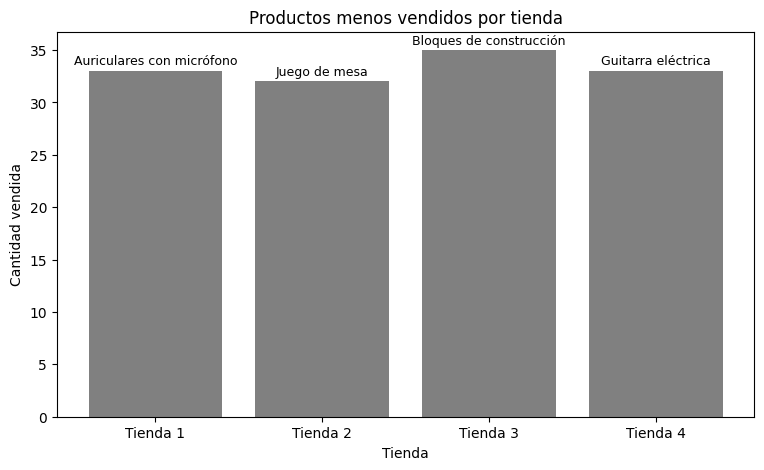

In [19]:
# --- Producto menos vendido de cada tienda ---

bottom_productos = {
    "Tienda 1": tienda['Producto'].value_counts().idxmin(),
    "Tienda 2": tienda2['Producto'].value_counts().idxmin(),
    "Tienda 3": tienda3['Producto'].value_counts().idxmin(),
    "Tienda 4": tienda4['Producto'].value_counts().idxmin(),
}

ventas_bottom = {
    "Tienda 1": tienda['Producto'].value_counts().min(),
    "Tienda 2": tienda2['Producto'].value_counts().min(),
    "Tienda 3": tienda3['Producto'].value_counts().min(),
    "Tienda 4": tienda4['Producto'].value_counts().min(),
}

# Crear DataFrame para graficar
df_bottom = pd.DataFrame({
    "Tienda": list(bottom_productos.keys()),
    "Producto menos vendido": list(bottom_productos.values()),
    "Cantidad vendida": list(ventas_bottom.values())
})

# --- Gráfico ---
plt.figure(figsize=(9,5))
plt.bar(df_bottom["Tienda"], df_bottom["Cantidad vendida"], color='grey')
plt.title("Productos menos vendidos por tienda")
plt.xlabel("Tienda")
plt.ylabel("Cantidad vendida")

# Mostrar etiquetas con el nombre del producto centrado y bien visible
for i, valor in enumerate(df_bottom["Cantidad vendida"]):
    plt.text(i, valor + 0.3, df_bottom["Producto menos vendido"][i], ha='center', va='bottom', fontsize=9, rotation=0, wrap=True)

plt.show()



---



###**Conclusión del análisis de productos**

En el análisis de los **productos más y menos vendidos**, se observa que cada tienda tiene un comportamiento distinto en sus ventas.

Algunas tiendas presentan **productos con una demanda claramente superior**, lo que puede indicar buena aceptación o estrategia de marketing efectiva.

Los **productos menos vendidos podrían estar relacionados con categorías menos populares o con precios más altos**.

Este análisis ayuda a identificar qué productos potenciar y cuáles revisar o reemplazar para mejorar el rendimiento general de las tiendas.



---



# 5. Envío promedio por tienda

In [21]:
# Calcular el costo de envío promedio para cada tienda
envio_tienda1 = tienda['Costo de envío'].mean()
envio_tienda2 = tienda2['Costo de envío'].mean()
envio_tienda3 = tienda3['Costo de envío'].mean()
envio_tienda4 = tienda4['Costo de envío'].mean()

# Crear un DataFrame con los resultados
df_envio = pd.DataFrame({
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Envío Promedio': [envio_tienda1, envio_tienda2, envio_tienda3, envio_tienda4]
})

df_envio

,Tienda,Envío Promedio
0,Tienda 1,26018.609580
1,Tienda 2,25216.235693
2,Tienda 3,24805.680373
3,Tienda 4,23459.457167


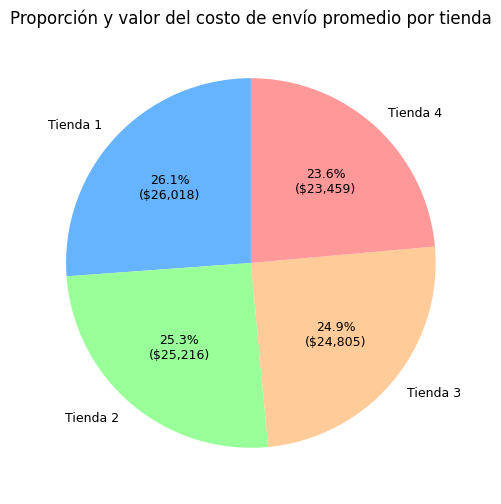

In [22]:
# --- Gráfico circular con valores y porcentajes ---
plt.figure(figsize=(6,6))

valores = df_envio["Envío Promedio"]
labels = df_envio["Tienda"]

# Función personalizada para mostrar valor + porcentaje
def etiqueta(pct, all_vals):
    valor_absoluto = int(pct/100.*sum(all_vals))
    return f"{pct:.1f}%\n(${valor_absoluto:,.0f})"

plt.pie(
    valores,
    labels=labels,
    autopct=lambda pct: etiqueta(pct, valores),
    startangle=90,
    colors=["#66b3ff","#99ff99","#ffcc99","#ff9999"],
    textprops={"fontsize": 9}
)

plt.title("Proporción y valor del costo de envío promedio por tienda", fontsize=12)
plt.show()

### **Análisis del costo de envío promedio por tienda**

El análisis muestra que las diferencias entre los costos de envío promedio de las tiendas son relativamente pequeñas:

- **Tienda 1**: $26,018  **(el más alto)**

- **Tienda 2**: $25,216.

- **Tienda 3**: $24,805.

- **Tienda 4**: $23,459  **(el más bajo)**

Aunque las variaciones no son significativas, la **Tienda 4** presenta una ligera ventaja competitiva al ofrecer el envío más económico. Este factor puede influir positivamente en la satisfacción del cliente y en las decisiones de compra, especialmente en mercados donde el costo de envío es un criterio relevante.




---

